Khởi tạo thư viện 

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
    mean_absolute_percentage_error
)

Đọc file 

In [3]:
df = pd.read_csv("zillow_final.csv")

print("Shape:", df.shape)
df.head()

Shape: (4468, 33)


,price,bed,bath,living,lot_sqft,lot_living,bed_bath,type_condo,type_manufactured,type_multi,...,risk_overall,risk_loss,risk_social,risk_resilience,risk_fire,risk_earthquake,risk_heat,dist_city,dist_airport,dist_coast
0,4980000.0,4.0,5.0,4126.0,4922.000,1.192923,0.8,False,False,False,...,80.718966,89.710407,9.209856,12.692809,73.920540,94.138632,8.354783,13.715619,17.888756,13.623171
1,1215000.0,3.0,2.0,1825.0,7840.800,4.296329,1.5,False,False,False,...,75.714982,83.604998,23.062252,12.692809,18.467649,89.615069,13.904381,39.379252,34.192540,22.666476
2,2629000.0,4.0,4.0,3019.0,43381.404,14.369461,1.0,False,False,False,...,92.322785,96.534514,9.209856,12.692809,98.160370,93.614213,13.158396,18.768005,19.185657,11.646300
3,400000.0,3.0,2.0,944.0,4268.880,4.522119,1.5,False,False,True,...,68.423055,43.952134,93.082983,12.692809,0.000000,93.975717,20.717146,9.473542,11.193127,18.586372
4,849000.0,2.0,2.0,1154.0,5002.000,4.334489,1.0,False,False,False,...,53.028195,54.870000,40.578096,12.692809,0.000000,87.909814,8.907717,37.911992,27.545766,35.124601


Tách X thành các features và Y là cột price 

In [4]:
# Bỏ dòng thiếu price nếu có
df = df.dropna(subset=["price"])

X = df.drop(columns=["price"])
y = df["price"]

# Nếu có bool True/False thì đổi sang 0/1
for col in X.select_dtypes(include=["bool"]).columns:
    X[col] = X[col].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4468, 32)
y shape: (4468,)


Chia thành 2 tập train và test : Train chiếm 80% dữ liệu , còn test chiếm 20% dữ liệu.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Hàm đánh giá

In [11]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    median_ae = median_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print("=" * 55)
    print(model_name)
    print("=" * 55)
    print(f"MAE       : {mae:,.0f}")
    print(f"Median AE : {median_ae:,.0f}")
    print(f"RMSE      : {rmse:,.0f}")
    print(f"R2        : {r2:.4f}")
    print(f"MAPE      : {mape:.2f}%")
    print()

Emsemble dùng log(price)

In [12]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# Train với log(price)
y_train_log = np.log1p(y_train)

rf_model.fit(X_train, y_train_log)

# Predict log(price)
y_pred_log = rf_model.predict(X_test)

# Đổi ngược về giá thật
y_pred_rf = np.expm1(y_pred_log)

evaluate_model(
    "Random Forest Only - Log Price",
    y_test,
    y_pred_rf
)

Random Forest Only - Log Price
MAE       : 901,423
Median AE : 136,784
RMSE      : 4,606,196
R2        : 0.6206
MAPE      : 23.15%



Bảng kết quả Random Forest Log Price

In [15]:
def get_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "Median AE": median_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
        "MAPE (%)": mean_absolute_percentage_error(y_true, y_pred) * 100
    }

results = pd.DataFrame([
    get_metrics("Random Forest Only - Log Price", y_test, y_pred_rf)
])

results

,Model,MAE,Median AE,RMSE,R2,MAPE (%)
0,Random Forest Only - Log Price,901422.651528,136784.172195,4.606196e+06,0.620575,23.145043


In [17]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
2,living,0.197042
1,bath,0.133859
19,area_home_value,0.109134
17,bachelor,0.056754
0,bed,0.056357
13,income,0.053312
5,bed_bath,0.051543
31,dist_coast,0.050594
30,dist_airport,0.030270
18,rent,0.030023


Vẽ feature importance

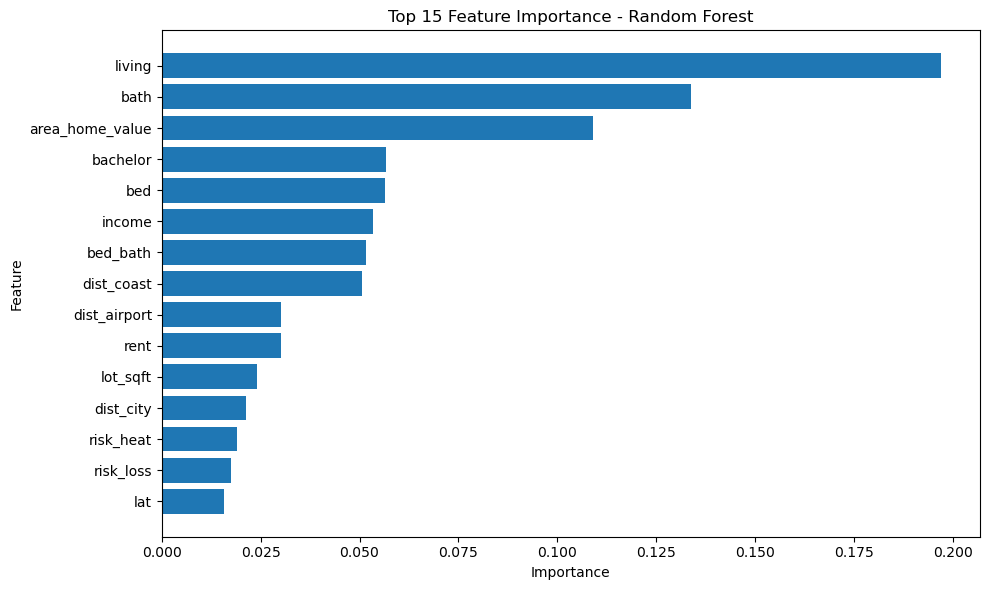

In [18]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Random Forest")
plt.tight_layout()
plt.show()